In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Data Descriptions

In [2]:
input_states = np.load("/cis/home/jye/Workspace/rnn_eda/data/share_mats/softplus/0/test/trial_input.npz")
hidden_states = np.load("/cis/home/jye/Workspace/rnn_eda/data/share_mats/softplus/0/test/state.npz")
output_states = np.load("/cis/home/jye/Workspace/rnn_eda/data/share_mats/softplus/0/test/trial_output.npz")

In [3]:
print('--------------INPUT STATES--------------')
for task_name in list(input_states.keys()):
    print(f"{task_name}: {input_states[task_name].shape}")

print("--------------HIDDEN STATES--------------")
for task_name in list(hidden_states.keys()):
    print(f"{task_name}: {hidden_states[task_name].shape}")

print('--------------OUTPUT STATES--------------')
for task_name in list(output_states.keys()):
    print(f"{task_name}: {output_states[task_name].shape}")

--------------INPUT STATES--------------
reactgo: (125, 80, 20)
delaygo: (125, 80, 20)
contextdelaydm1: (175, 640, 20)
fdgo: (100, 80, 20)
multidelaydm: (175, 640, 20)
fdanti: (100, 80, 20)
delaydm1: (150, 160, 20)
delaydm2: (150, 160, 20)
contextdelaydm2: (175, 640, 20)
dmcnogo: (135, 160, 20)
delayanti: (125, 80, 20)
reactanti: (125, 80, 20)
dmsnogo: (135, 160, 20)
dmsgo: (135, 160, 20)
dmcgo: (135, 160, 20)
--------------HIDDEN STATES--------------
reactgo: (125, 80, 128)
delaygo: (125, 80, 128)
contextdelaydm1: (175, 640, 128)
fdgo: (100, 80, 128)
multidelaydm: (175, 640, 128)
fdanti: (100, 80, 128)
delaydm1: (150, 160, 128)
delaydm2: (150, 160, 128)
contextdelaydm2: (175, 640, 128)
dmcnogo: (135, 160, 128)
delayanti: (125, 80, 128)
reactanti: (125, 80, 128)
dmsnogo: (135, 160, 128)
dmsgo: (135, 160, 128)
dmcgo: (135, 160, 128)
--------------OUTPUT STATES--------------
reactgo: (125, 80, 3)
delaygo: (125, 80, 3)
contextdelaydm1: (175, 640, 3)
fdgo: (100, 80, 3)
multidelaydm: (175, 

In [4]:
epoch_starts = {task_name: np.array(0) for task_name in list(input_states.keys())}
for task_name in list(input_states.keys()):
    # plt.figure()
    # plt.matshow(input_states[task_name][:, 0, :].T)
    # plt.title(task_name)

    _temp_state = input_states[task_name][:, 0, :].T
    first_5 = _temp_state[:5]
    switch_indices = np.where(np.any(first_5[:, 1:] != first_5[:, :-1], axis=0))[0] + 1
    epoch_starts[task_name] = np.append(epoch_starts[task_name], switch_indices)
    epoch_starts[task_name] = np.append(epoch_starts[task_name], input_states[task_name].shape[0])

In [5]:
epoch_starts

{'reactgo': array([  0, 100, 125]),
 'delaygo': array([  0,  25,  50, 100, 125]),
 'contextdelaydm1': array([  0,  25,  50, 100, 125, 150, 175]),
 'fdgo': array([  0,  25,  75, 100]),
 'multidelaydm': array([  0,  25,  50, 100, 125, 150, 175]),
 'fdanti': array([  0,  25,  75, 100]),
 'delaydm1': array([  0,  25,  50, 100, 125, 135, 150]),
 'delaydm2': array([  0,  25,  50, 100, 125, 135, 150]),
 'contextdelaydm2': array([  0,  25,  50, 100, 125, 150, 175]),
 'dmcnogo': array([  0,  25,  50, 110, 135]),
 'delayanti': array([  0,  25,  50, 100, 125]),
 'reactanti': array([  0, 100, 125]),
 'dmsnogo': array([  0,  25,  50, 110, 135]),
 'dmsgo': array([  0,  25,  50, 110, 135]),
 'dmcgo': array([  0,  25,  50, 110, 135])}

In [6]:
epoch_labels = {
    "react": ["Init", "Response"],
    "fd": ["Init", "Stim 1", "Response"],
    "delay": ["Init", "Stim 1", "Memory 1", "Response"],
    "dm": ["Init", "Stim 1", "Memory 1", "Stim2/Response"],
    "delaydm": ["Init", "Stim 1", "Memory 1", "Stim 2 ", "Memory 2", "Response"],
}

In [7]:
avg_acts_per_epoch = []
avg_std_per_epoch = []
epoch_label = []
for task_name in list(hidden_states.keys()):
    epoch_idxs = list(epoch_starts[task_name])
    for i in range(len(epoch_idxs)-1):
        epoch_weights = hidden_states[task_name][epoch_idxs[i]:epoch_idxs[i+1], :, :] 
        avg_acts_per_neuron = np.mean(epoch_weights, axis=(0,1))

        if sum([a>2 for a in avg_acts_per_neuron])>0:
            print(avg_acts_per_neuron)
        avg_std_per_neuron = np.std(epoch_weights, axis=(0,1))
        avg_acts_per_epoch.append(avg_acts_per_neuron)
        avg_std_per_epoch.append(avg_std_per_neuron)

        if task_name in ["reactgo", "reactanti"]:
            epoch_label.append(f'{task_name} {epoch_labels['react'][i]}')
        elif task_name in ["fdgo", "fdanti"]:
            epoch_label.append(f'{task_name} {epoch_labels['fd'][i]}')
        elif task_name in ["delaygo", "delayanti"]:
            epoch_label.append(f'{task_name} {epoch_labels['delay'][i]}')
        elif task_name in ["dmsgo", "dmsnogo", "dmcgo", "dmcnogo"]:
            epoch_label.append(f'{task_name} {epoch_labels['dm'][i]}')
        elif task_name in ["delaydm1", "delaydm2", "contextdelaydm1", "contextdelaydm2", "multidelaydm"]:
            epoch_label.append(f'{task_name} {epoch_labels['delaydm'][i]}')
        else:
            print(f"Task name {task_name} not found in labels")
            
avg_acts_per_epoch = np.array(avg_acts_per_epoch)
avg_std_per_epoch = np.array(avg_std_per_epoch)

# Heirarchical Sorting of Activations

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.preprocessing import StandardScaler

def sort_rows_and_cols_ward(X):
    # Cluster rows
    Z_rows = linkage(
        X,
        method="ward",
        optimal_ordering=False
    )
    row_dendro = dendrogram(
        Z_rows,
        no_plot=True
    )
    row_order = row_dendro["leaves"]

    # Cluster olumns
    Z_cols = linkage(
        X.T,
        method="ward",
        optimal_ordering=False
    )
    col_dendro = dendrogram(
        Z_cols,
        no_plot=True
    )
    col_order = col_dendro["leaves"]
    X_reordered = X[np.ix_(row_order, col_order)]

    return {
       "row_dendro": row_dendro,
       "col_dendro": col_dendro,
       "X_reordered": X_reordered 
    }

### Average Activations

RNN weights are chunked out by epoch and task. \
Then, we calculate the average activation within that epoch and task. \
In this analysis, stimuli are all roled into the epoch average.

Text(0.5, 0, 'Unit ID')

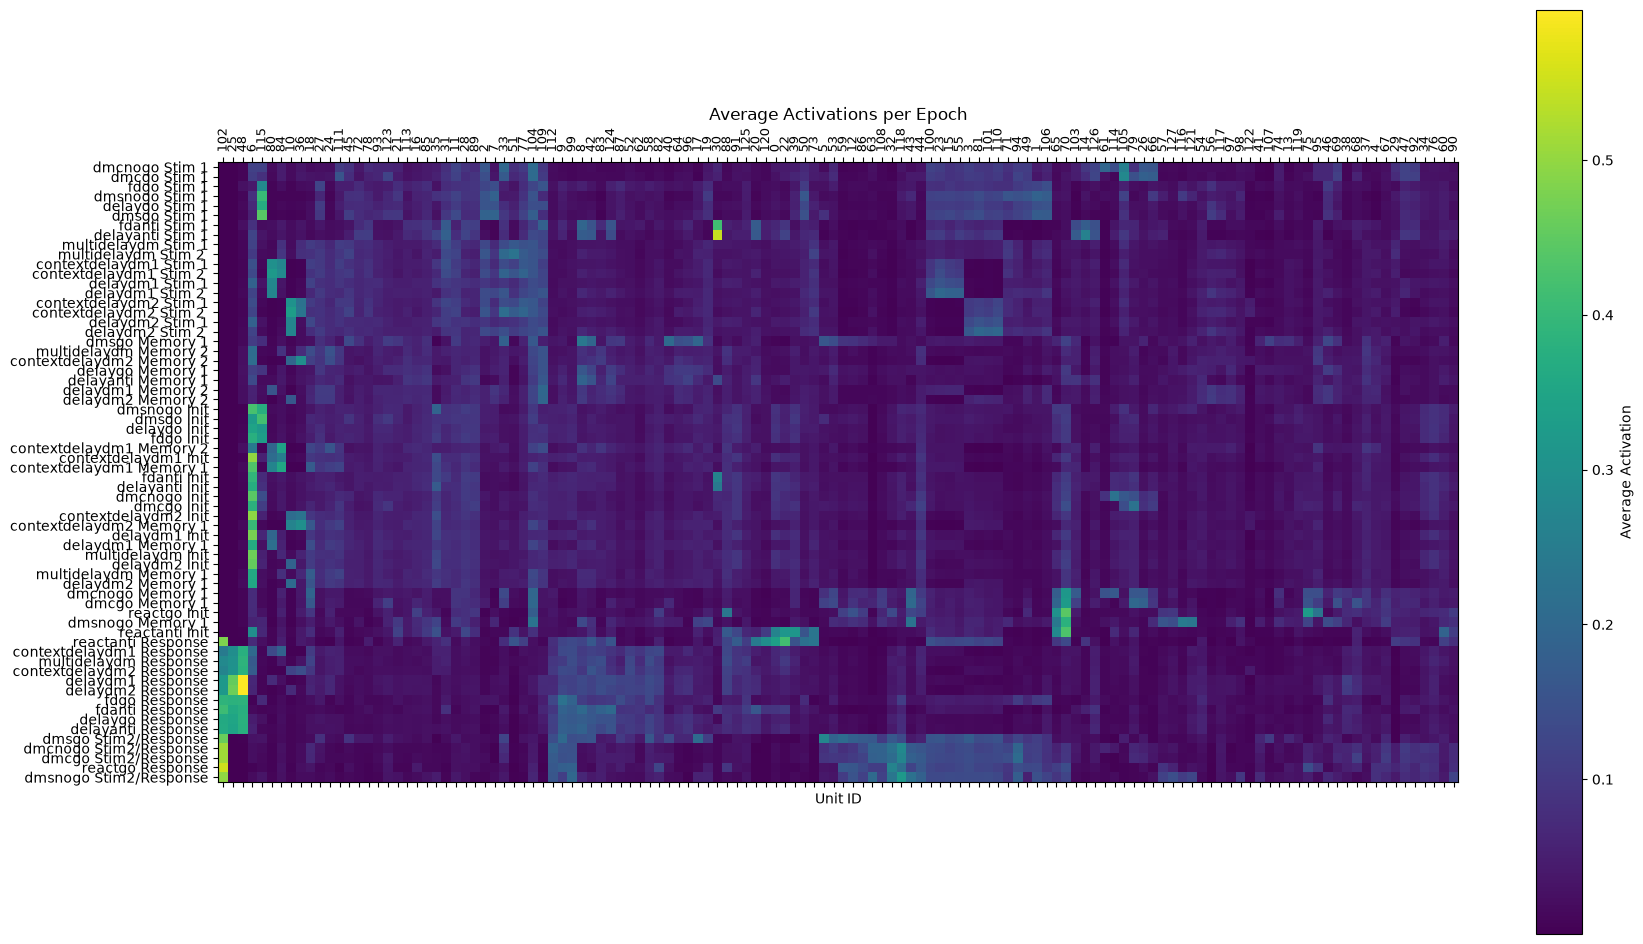

In [9]:
avg_acts_clustered = sort_rows_and_cols_ward(avg_acts_per_epoch)

fig, ax = plt.subplots(1,1, figsize=(20,12))

nrows, ncols = avg_acts_clustered['X_reordered'].shape

im = ax.matshow(avg_acts_clustered['X_reordered'])
plt.colorbar(im, label="Average Activation")
ax.set_yticks(range(len(epoch_label)))
ax.set_yticklabels(np.array(epoch_label)[avg_acts_clustered['row_dendro']['leaves']], fontsize=10)
ax.set_xticks(range(ncols))
ax.set_xticklabels(avg_acts_clustered['col_dendro']['leaves'], rotation=90, fontsize=9)
plt.title("Average Activations per Epoch")
plt.xlabel("Unit ID")

### Add bands/lines that denote breaks between epochs
### Long term -- group by actual epoch (e.g. "response" is next to "response")

In [10]:
# Lack of scpecificity of single units
# There is some sort of population structure 
# DLDS answers what is the decomposition of the population structure?

### Variance per epoch

RNN weights are chunked out by epoch and task. \
Then, we calculate the variance within that epoch and task. \
In this analysis, stimuli are all roled into the epoch average. \
Replicate Driscoll figure 3a (order is different than the driscoll figure)

Text(0.5, 0, 'Unit ID')

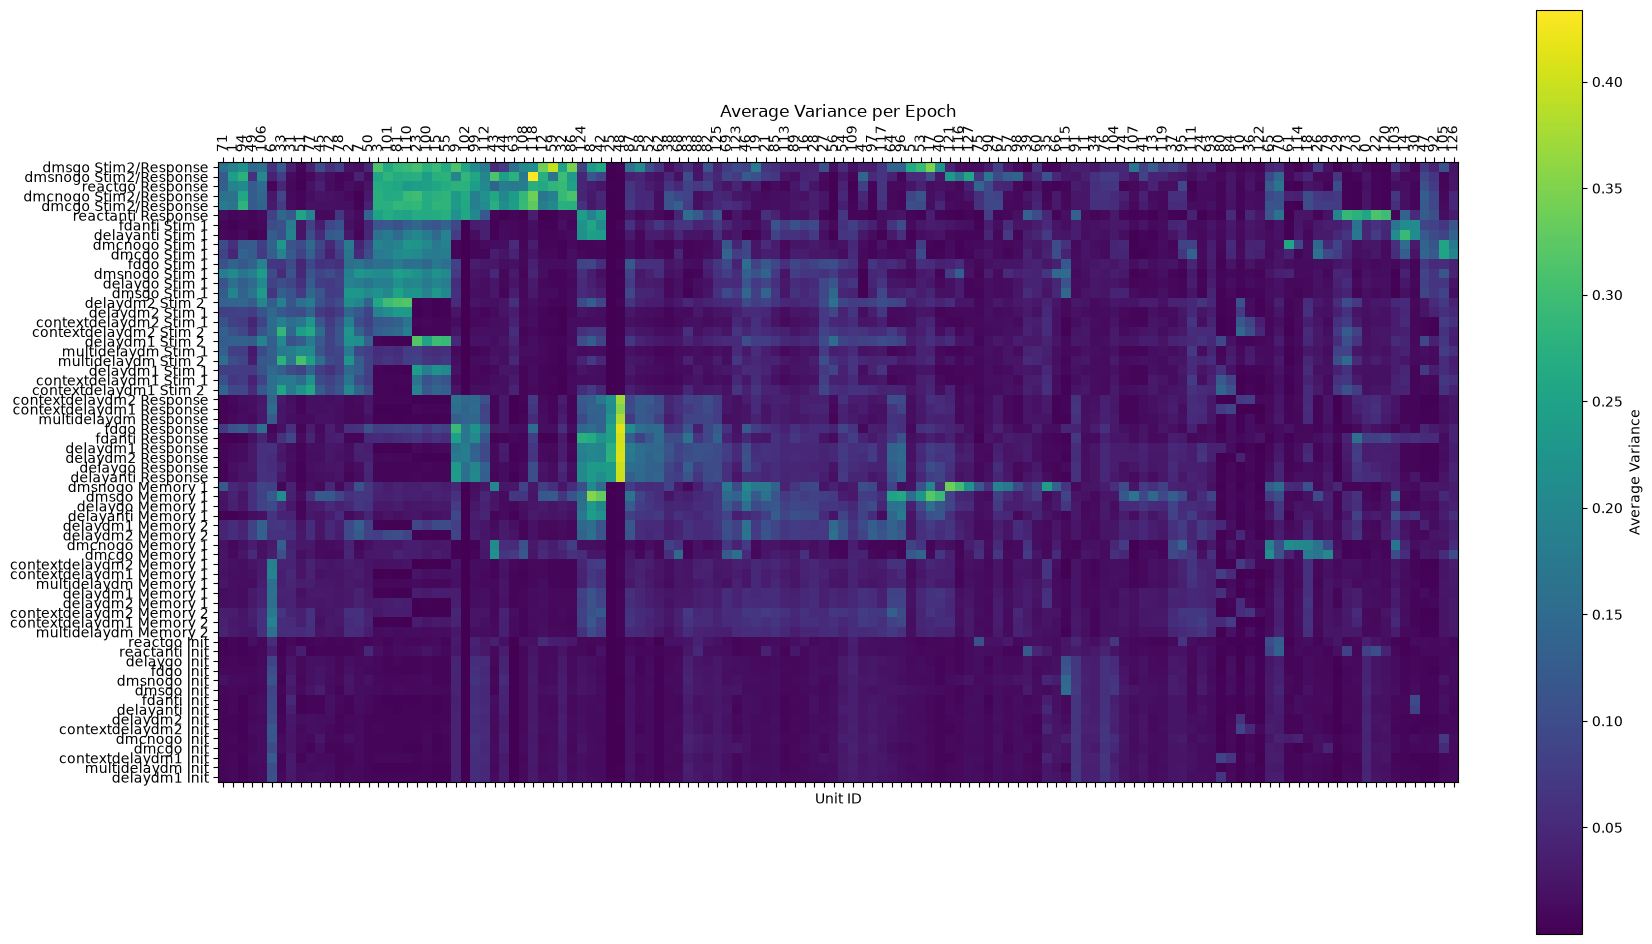

In [10]:
avg_stds_clustered = sort_rows_and_cols_ward(avg_std_per_epoch)

fig, ax = plt.subplots(1, 1, figsize=(20,12))

nrows, ncols = avg_stds_clustered['X_reordered'].shape

im = ax.matshow(avg_stds_clustered['X_reordered'])
plt.colorbar(im, label="Average Variance")
ax.set_yticks(range(len(epoch_label)))
ax.set_yticklabels(np.array(epoch_label)[avg_stds_clustered['row_dendro']['leaves']], fontsize=10)
ax.set_xticks(range(ncols))
ax.set_xticklabels(avg_stds_clustered['col_dendro']['leaves'], rotation=90, fontsize=10)
plt.title("Average Variance per Epoch")
plt.xlabel("Unit ID")

### Add bands/lines that denote breaks between epochs
### Long term -- group by actual epoch (e.g. "response" is next to "response")

# Heirarchical sorting of activations across stimuli

To detect whether there is any sort of stimulus preference/tuning within the activations, the above analysis were repeated WITHOUT averaging over stimuli.

In [11]:
avg_acts_per_epoch_perstim = {}
avg_std_per_epoch_perstim = {}
epoch_label = []
for task_name in list(hidden_states.keys()):
    epoch_idxs = list(epoch_starts[task_name])
    for i in range(len(epoch_idxs)-1):
        epoch_weights = hidden_states[task_name][epoch_idxs[i]:epoch_idxs[i+1], :, :] 
        avg_acts_per_neuron = np.mean(epoch_weights, axis=(0))
        avg_std_per_neuron = np.std(epoch_weights, axis=(0))

        if task_name in ["reactgo", "reactanti"]:
            epoch_name = f'{task_name} {epoch_labels['react'][i]}'
        elif task_name in ["fdgo", "fdanti"]:
            epoch_name = f'{task_name} {epoch_labels['fd'][i]}'
        elif task_name in ["delaygo", "delayanti"]:
            epoch_name = f'{task_name} {epoch_labels['delay'][i]}'
        elif task_name in ["dmsgo", "dmsnogo", "dmcgo", "dmcnogo"]:
            epoch_name = f'{task_name} {epoch_labels['dm'][i]}'
        elif task_name in ["delaydm1", "delaydm2", "contextdelaydm1", "contextdelaydm2", "multidelaydm"]:
            epoch_name = f'{task_name} {epoch_labels['delaydm'][i]}'
        else:
            print(f"Task name {task_name} not found in labels")

        avg_acts_per_epoch_perstim[epoch_name] = avg_acts_per_neuron
        avg_std_per_epoch_perstim[epoch_name] = avg_std_per_neuron

In [12]:
def plot_clusters_per_epoch_and_stim(X:dict, colorbar_label:str=None):
    for epoch_type in ["Init", "Stim 1", "Memory 1", "Stim 2", "Memory 2", "Response"]:
        epoch_arr = []
        epoch_tasklabels = []
        for epoch_name, avg_epoch_acts in X.items():
            if epoch_type in epoch_name:
                epoch_arr.append(avg_epoch_acts)
                epoch_tasklabels.extend([epoch_name] * avg_epoch_acts.shape[0])
        epoch_arr = np.vstack(epoch_arr)
        print(f"Created {epoch_type} array: {epoch_arr.shape}")

        epoch_arr_clustered = sort_rows_and_cols_ward(epoch_arr)

        fig, ax = plt.subplots(1, 1, figsize=(12,8))
        plt.title(epoch_type)
        im = ax.matshow(epoch_arr_clustered["X_reordered"], aspect='auto')

        plt.colorbar(im, label=colorbar_label)

        tick_positions = np.arange(0, len(epoch_tasklabels), 100)
        ax.set_yticks(tick_positions)
        labels = np.array(epoch_tasklabels)[epoch_arr_clustered['row_dendro']['leaves']]
        ax.set_yticklabels(labels[tick_positions], fontsize=8)

        col_labels = epoch_arr_clustered['col_dendro']['leaves']
        ax.set_xticks(range(len(col_labels)))
        ax.set_xticklabels(col_labels, fontsize=5, rotation=90)
        plt.show()

### Average activations accross stimuli (per epoch and task)

Created Init array: (3360, 128)


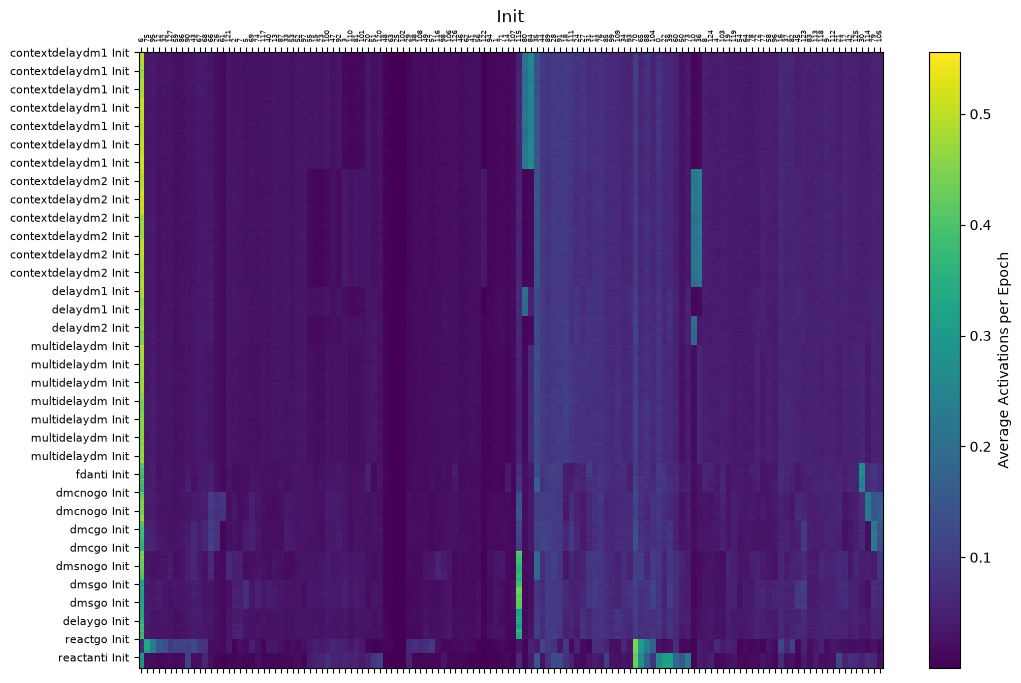

Created Stim 1 array: (3200, 128)


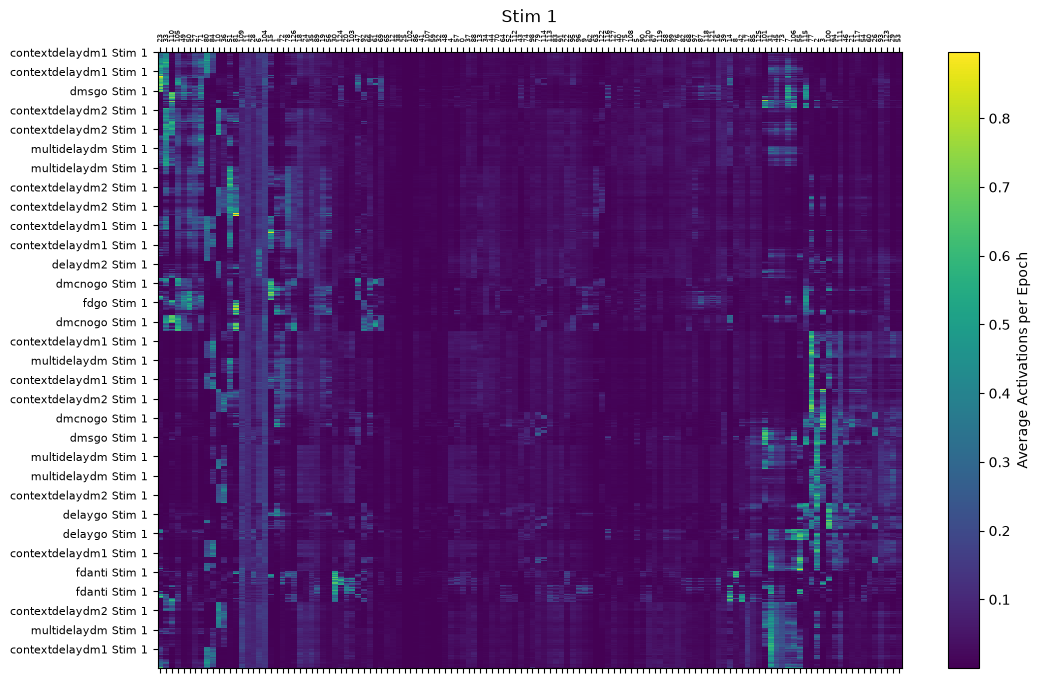

Created Memory 1 array: (3040, 128)


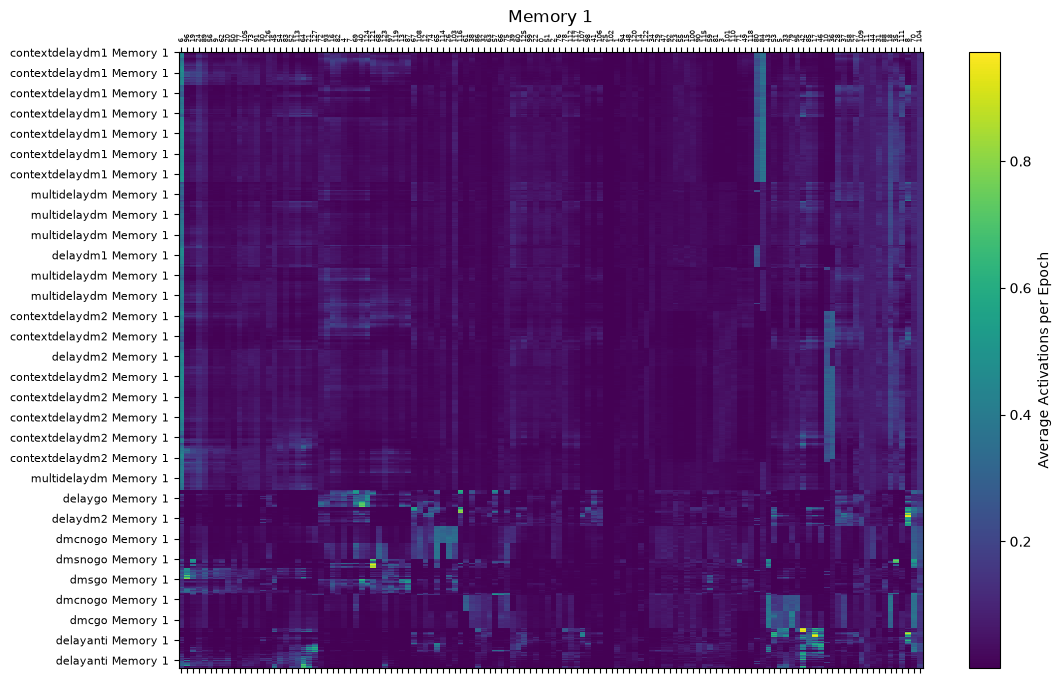

Created Stim 2 array: (2240, 128)


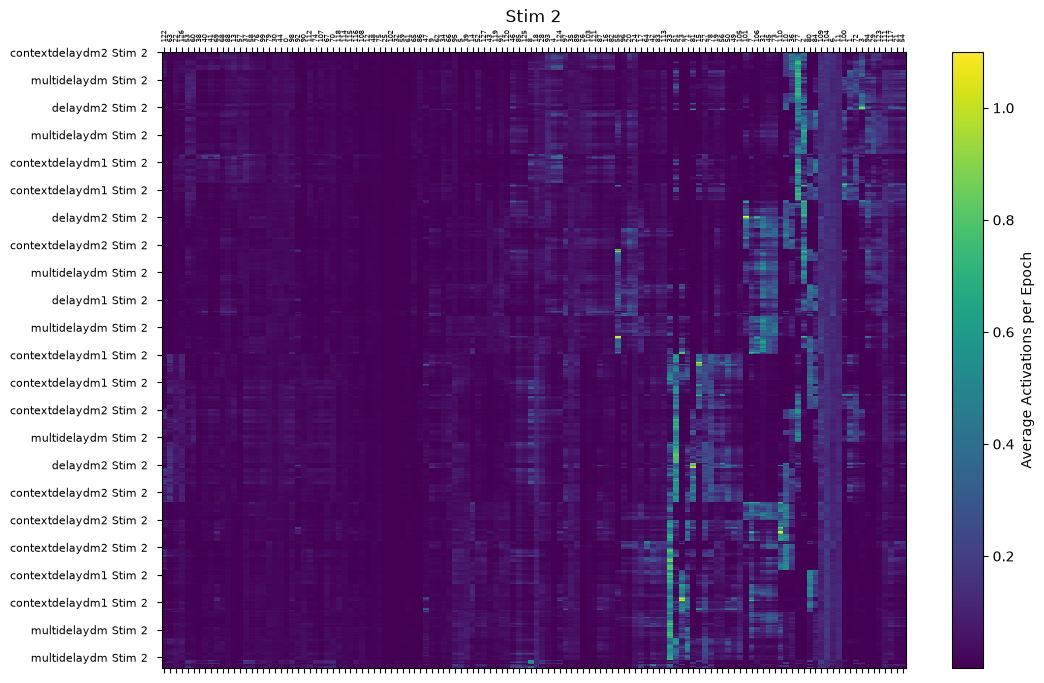

Created Memory 2 array: (2240, 128)


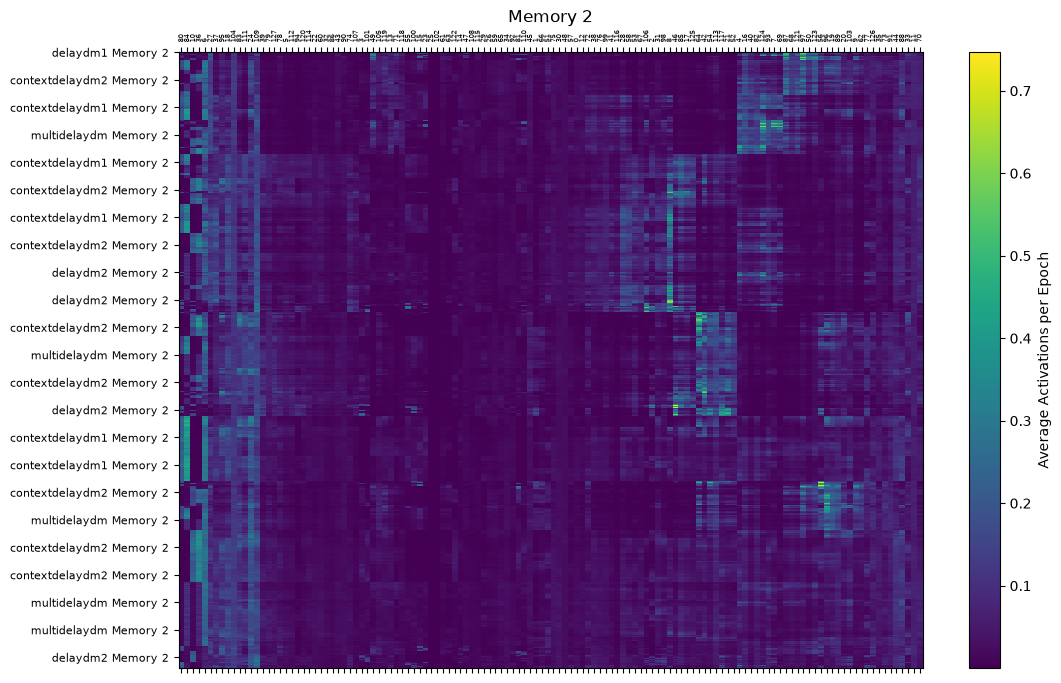

Created Response array: (3360, 128)


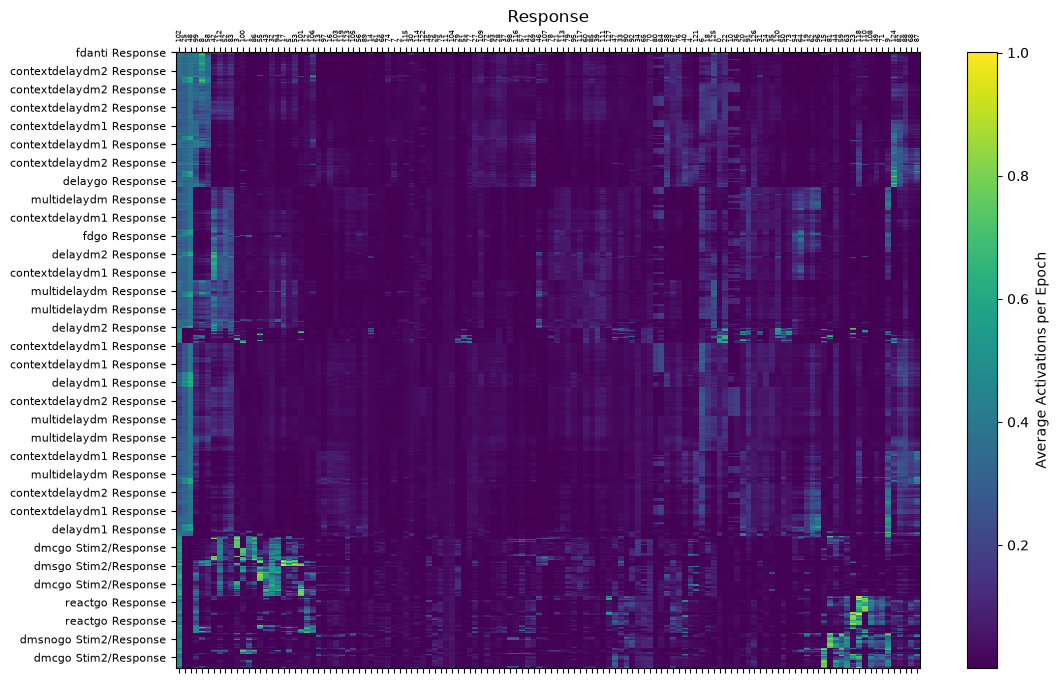

In [13]:
plot_clusters_per_epoch_and_stim(avg_acts_per_epoch_perstim, colorbar_label="Average Activations per Epoch")

### Average variance accross stimuli (per epoch and task)

Created Init array: (3360, 128)


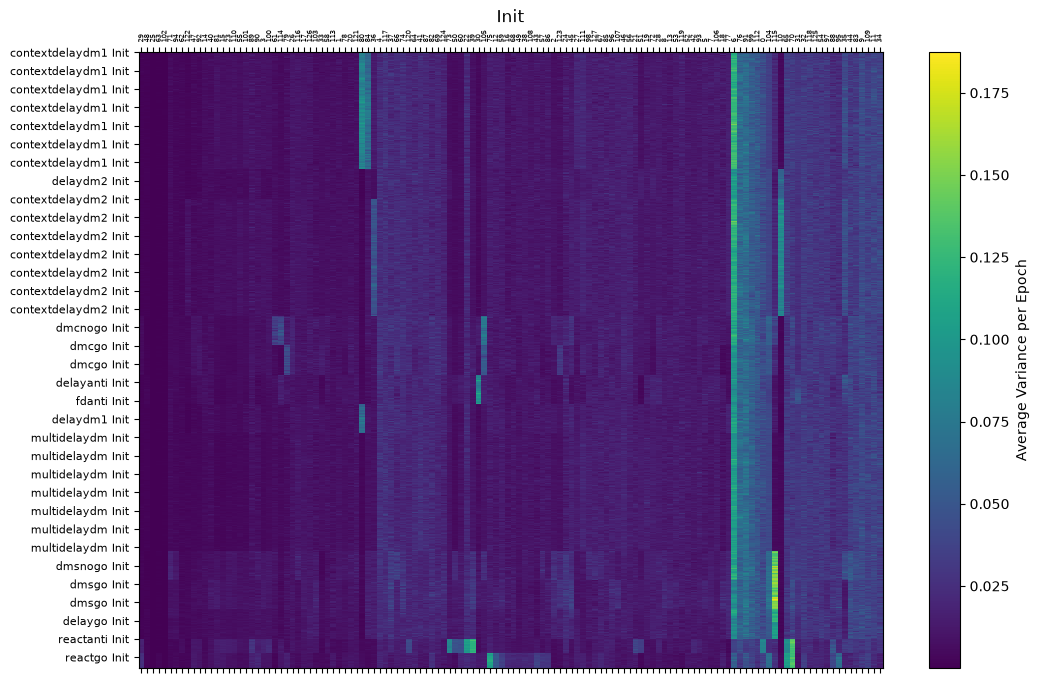

Created Stim 1 array: (3200, 128)


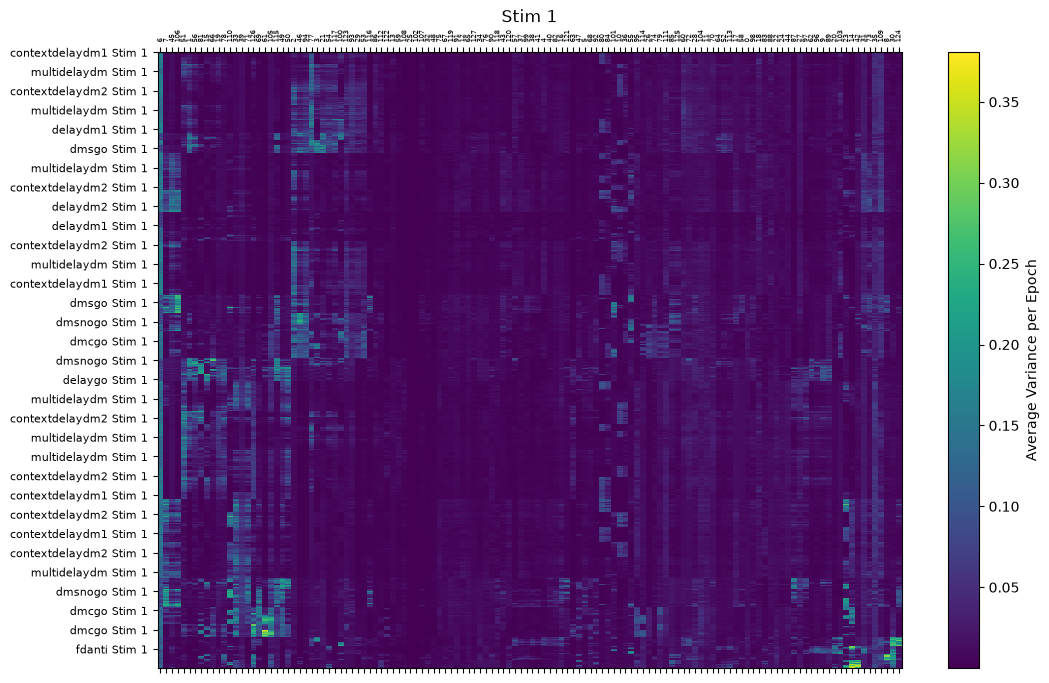

Created Memory 1 array: (3040, 128)


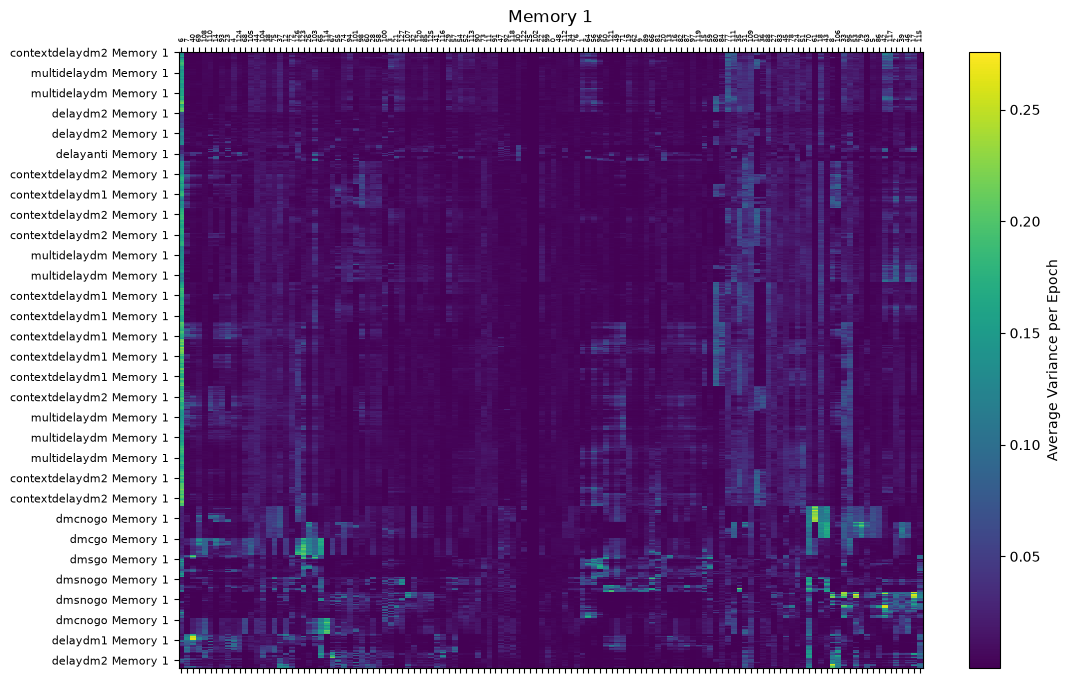

Created Stim 2 array: (2240, 128)


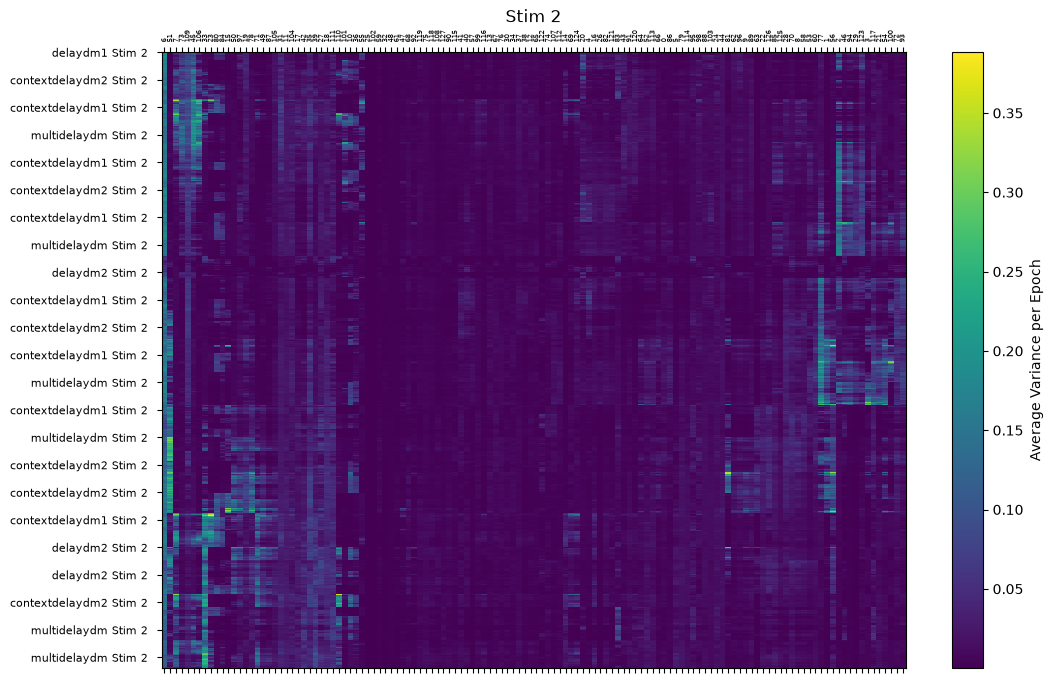

Created Memory 2 array: (2240, 128)


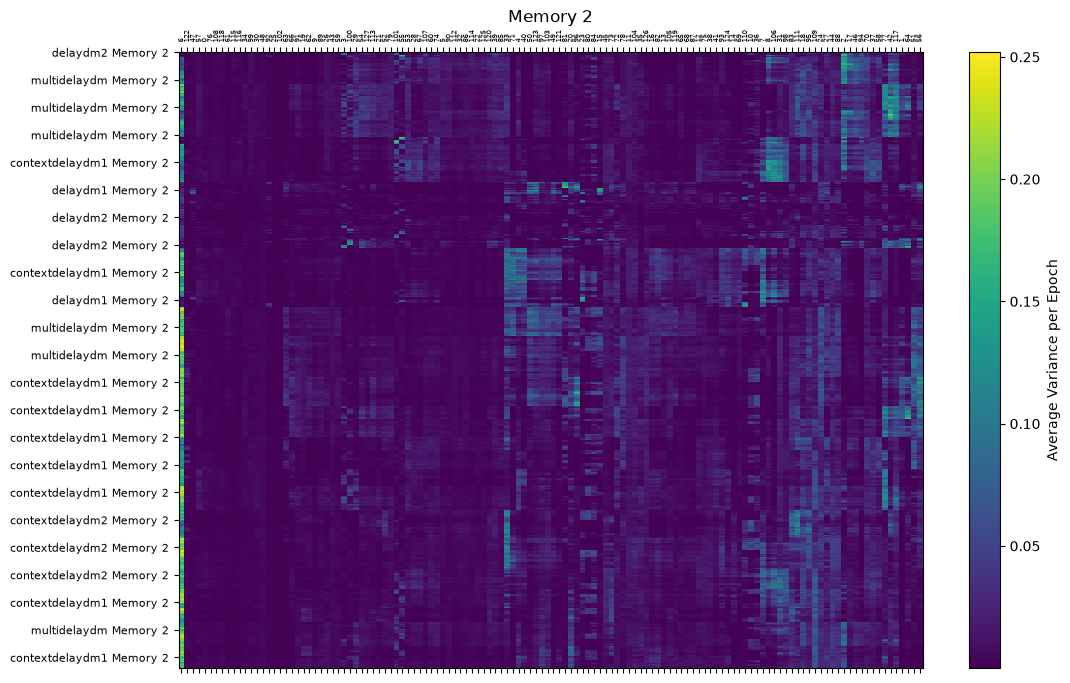

Created Response array: (3360, 128)


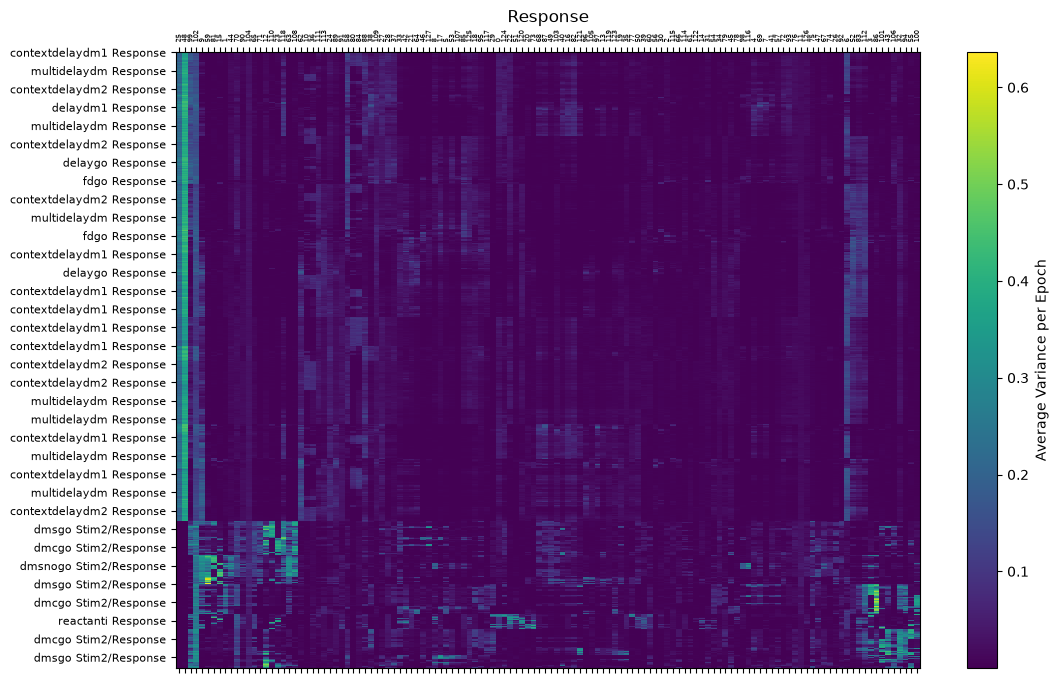

In [14]:
plot_clusters_per_epoch_and_stim(avg_std_per_epoch_perstim, colorbar_label="Average Variance per Epoch")

### PCA-based subspace analysis

PCA was fit independently to each epoch–task chunk, and each resulting PCA model was used to project all other epoch–task chunks. The explained variance ratio is plotted per-PC.

In [19]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm

n_components = 10

# Store PCA components and labels for every task+epoch chunk
pca_objects = []
pca_labels = []
epoch_chunks_raw = []

for task_name in tqdm(hidden_states.keys()):
    epoch_idxs = list(epoch_starts[task_name])
    for i in range(len(epoch_idxs) - 1):
        epoch_weights = hidden_states[task_name][
            epoch_idxs[i]:epoch_idxs[i + 1], :, :
        ]
        # (time, batch, features) -> (time * batch, features)
        X = epoch_weights.reshape(-1, epoch_weights.shape[-1])
        # Fit PCA independently to this task+epoch chunk
        pca = PCA(n_components=n_components)
        pca.fit(X)
        pca_objects.append(pca)
        epoch_chunks_raw.append(X)

        if task_name in ["reactgo", "reactanti"]:
            labels.append(f'{task_name} {epoch_labels['react'][i]}')
        elif task_name in ["fdgo", "fdanti"]:
            labels.append(f'{task_name} {epoch_labels['fd'][i]}')
        elif task_name in ["delaygo", "delayanti"]:
            labels.append(f'{task_name} {epoch_labels['delay'][i]}')
        elif task_name in ["dmsgo", "dmsnogo", "dmcgo", "dmcnogo"]:
            labels.append(f'{task_name} {epoch_labels['dm'][i]}')
        elif task_name in ["delaydm1", "delaydm2", "contextdelaydm1", "contextdelaydm2", "multidelaydm"]:
            labels.append(f'{task_name} {epoch_labels['delaydm'][i]}')
        else:
            print(f"Task name {task_name} not found in labels")


100%|██████████| 15/15 [00:12<00:00,  1.23it/s]


In [69]:
N = len(pca_objects)
# N = 5
variances_explained_percomponent = np.zeros((N, N, n_components))

for i in tqdm(range(N)):
    for j in range(N):

        pca = PCA(n_components=n_components)

        X_fit = epoch_chunks_raw[i]
        pca.fit(X_fit)
        X_transformed = pca.transform(epoch_chunks_raw[j])

        explained_variance = np.var(X_transformed, axis=0, ddof=1)
        total_variance = np.var(X_transformed, axis=0, ddof=1).sum()
        explained_variance_ratio = explained_variance / total_variance

        variances_explained_percomponent[i, j, :] = explained_variance_ratio


100%|██████████| 64/64 [08:04<00:00,  7.57s/it]


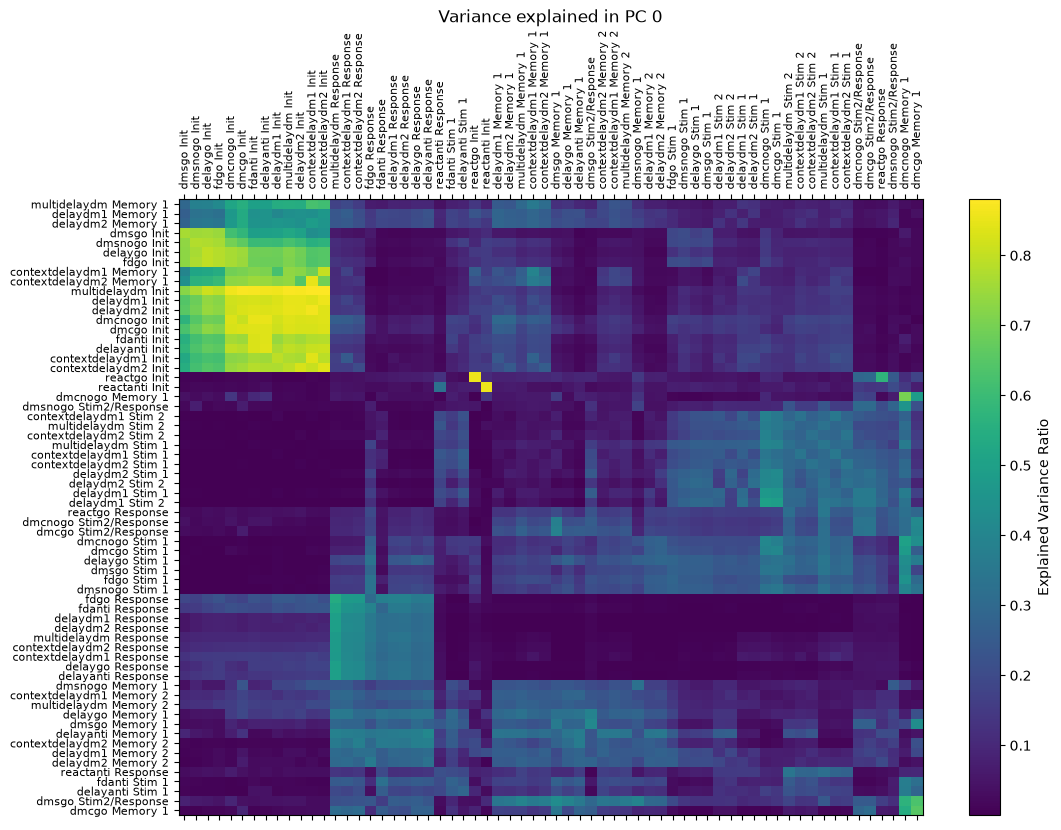

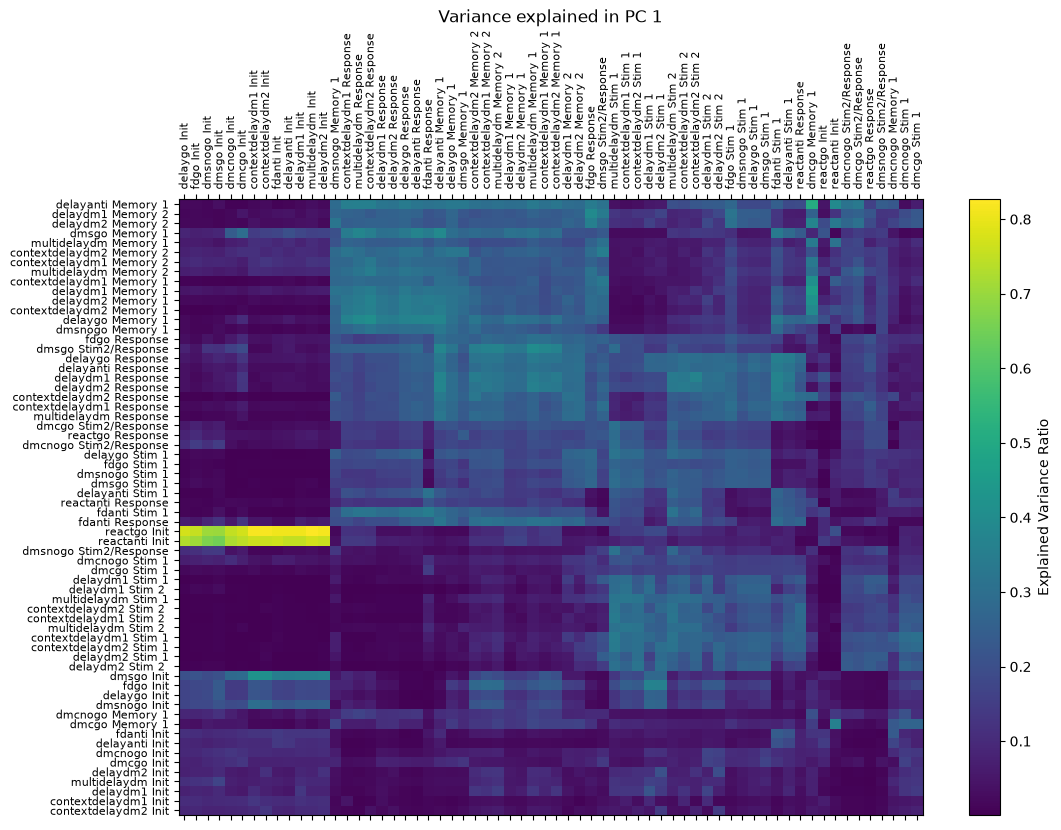

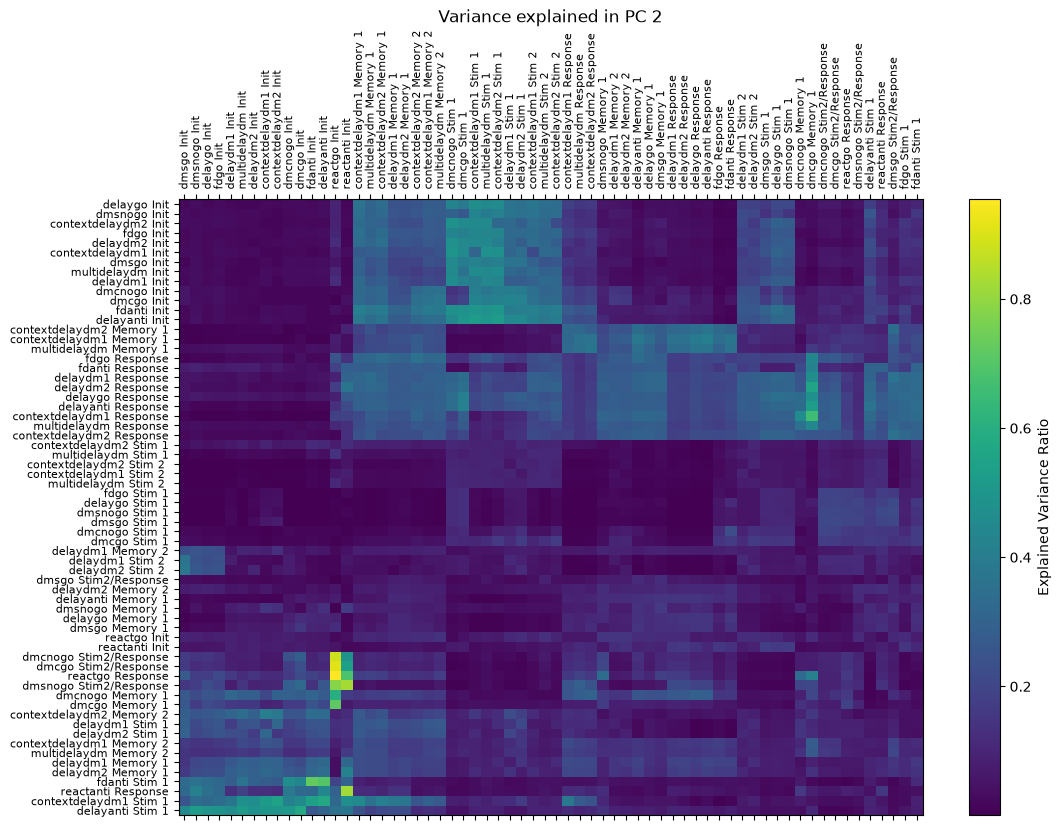

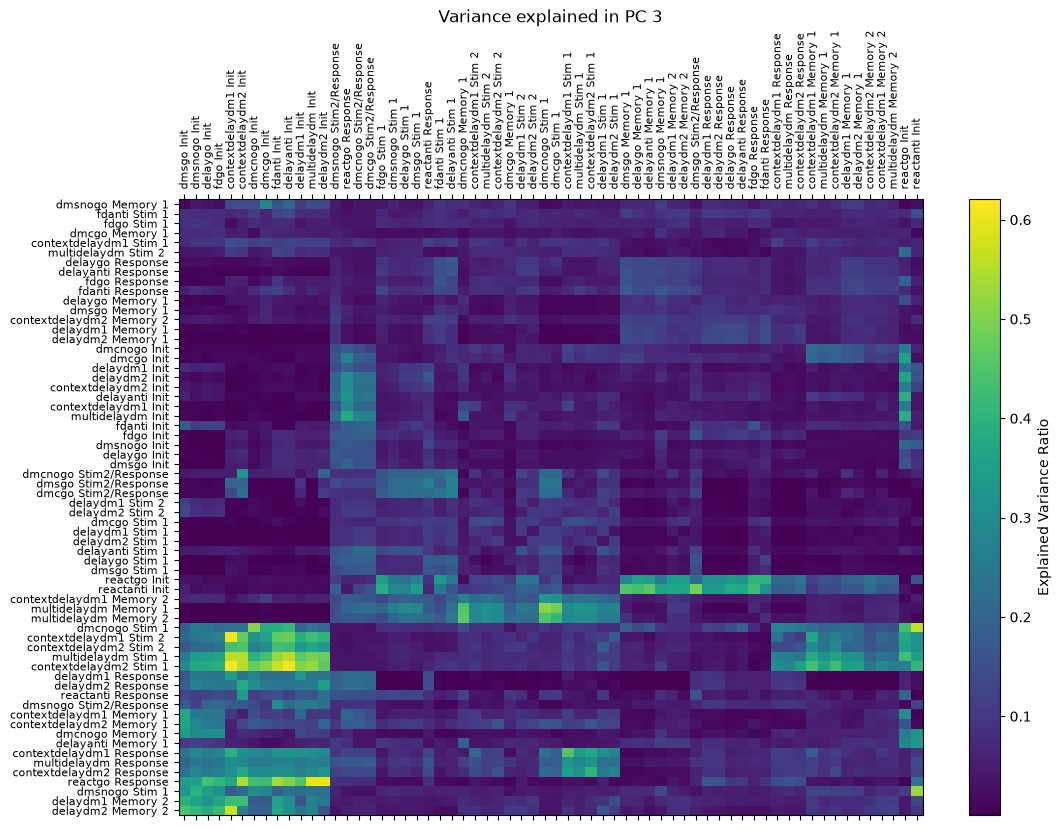

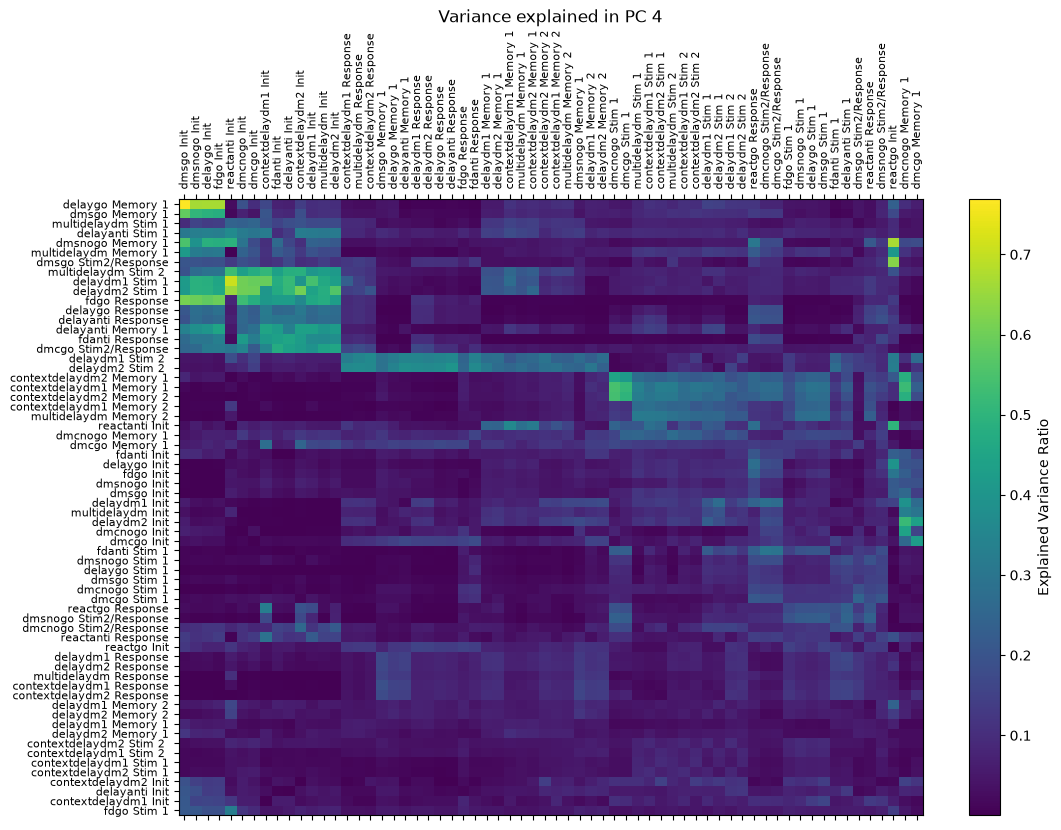

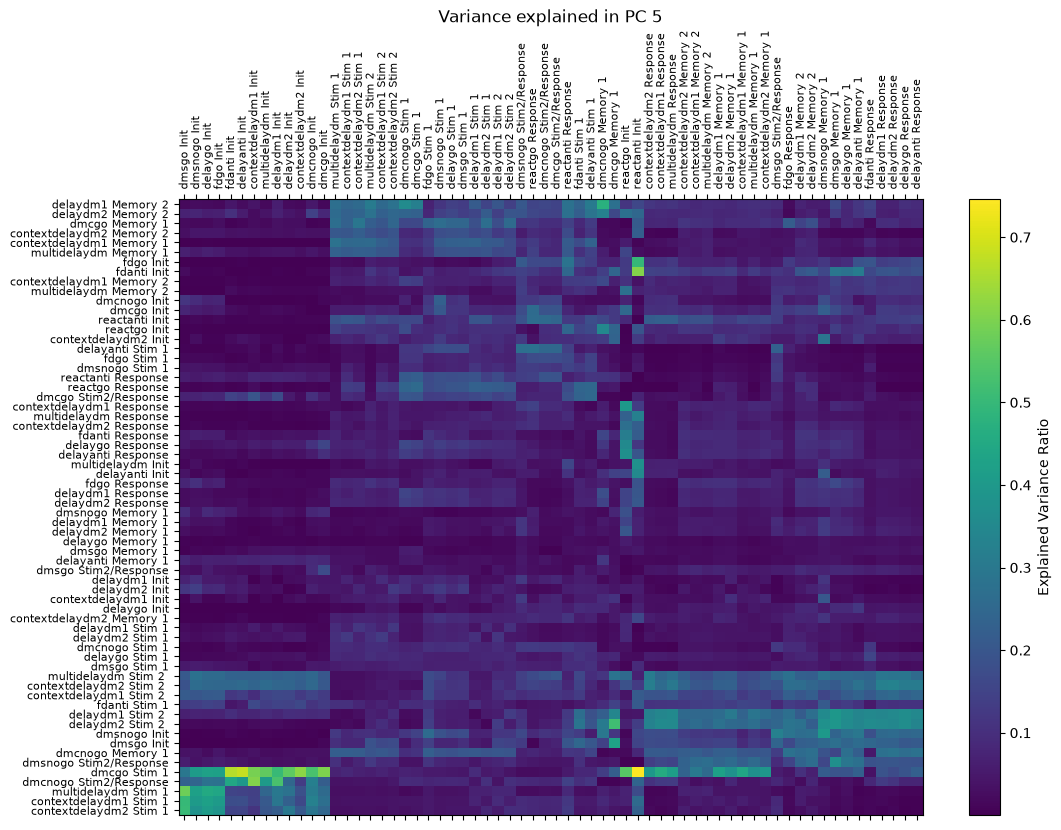

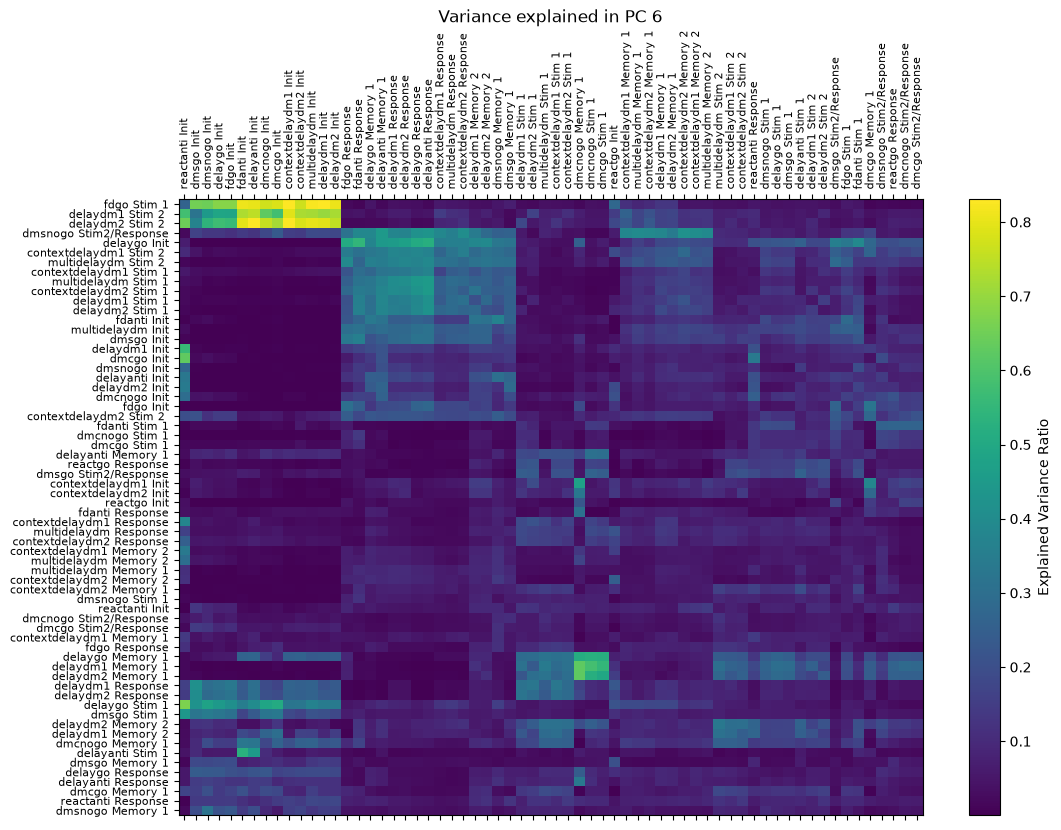

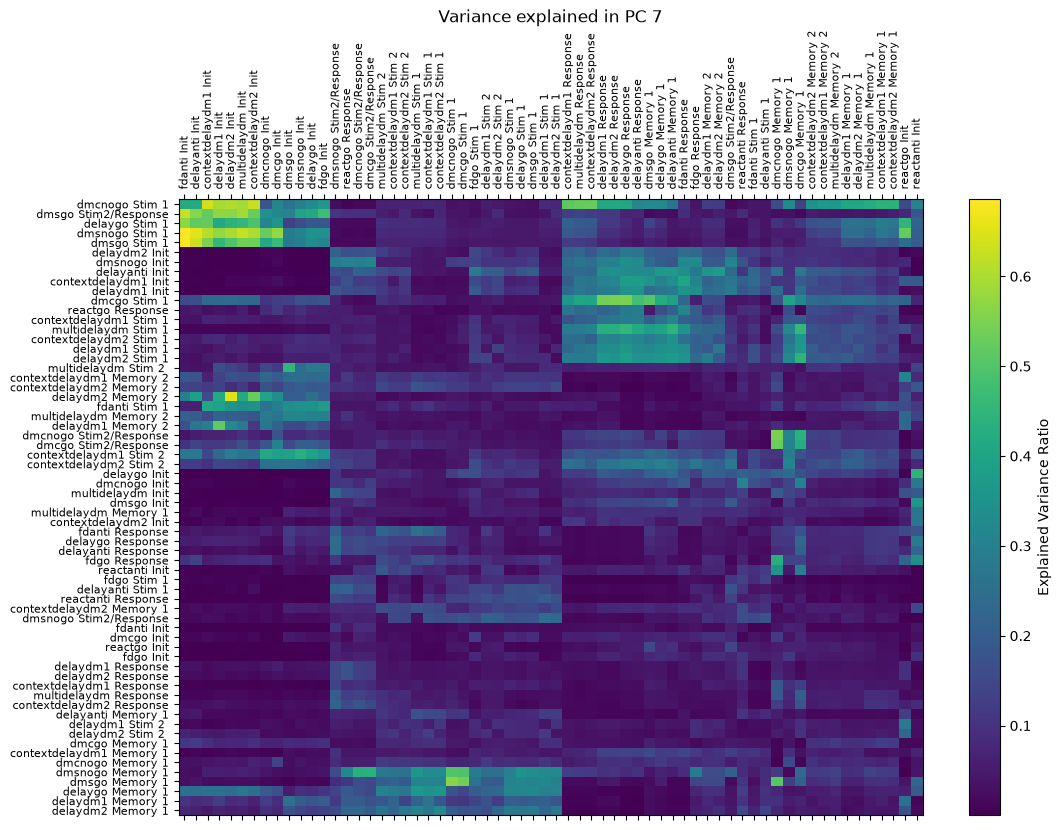

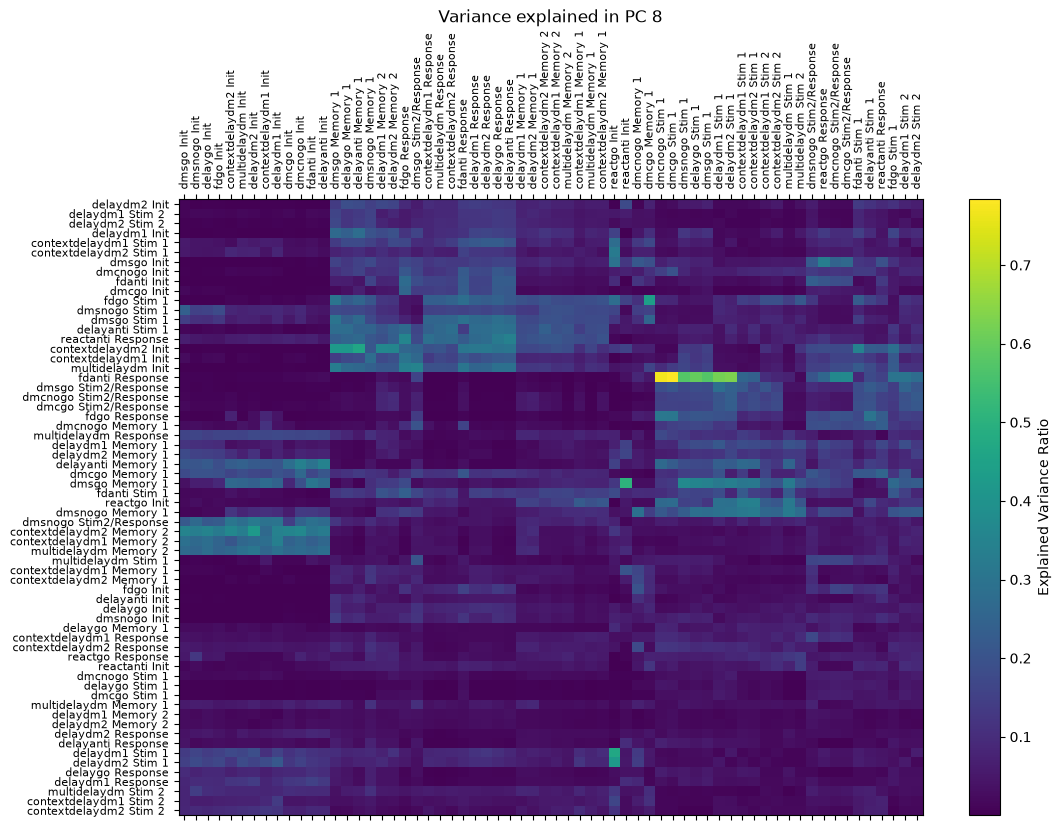

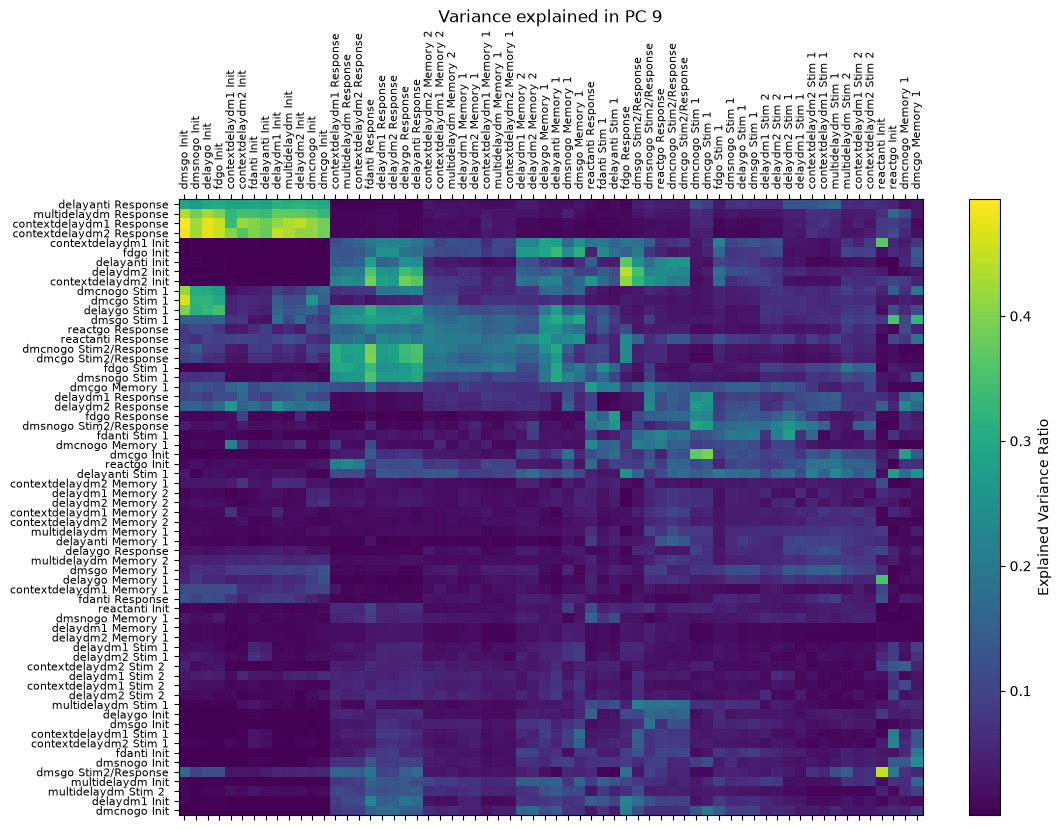

In [75]:
for i in range(n_components):
    explained_var_clustered = sort_rows_and_cols_ward(variances_explained_percomponent[:,:,i])

    fig, ax = plt.subplots(1, 1, figsize=(12,8))
    plt.title(f"Variance explained in PC {i}")
    im = ax.matshow(explained_var_clustered["X_reordered"], aspect='auto')

    plt.colorbar(im, label="Explained Variance Ratio")

    tick_positions = np.arange(0, len(pca_labels))
    row_labels = np.array(pca_labels)[explained_var_clustered['row_dendro']['leaves']]
    ax.set_yticks(tick_positions)
    ax.set_yticklabels(row_labels[tick_positions], fontsize=8)

    col_labels = np.array(pca_labels)[explained_var_clustered['col_dendro']['leaves']]
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(col_labels[tick_positions], fontsize=8, rotation=90)
    plt.show()

In [ ]:
# Lack of scpecificity of single units
# There is some sort of population structure 
# DLDS answers what is the decomposition of the population structure?